In [27]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 6.9 MB/s eta 0:00:00


In [30]:
from xgboost import XGBRegressor
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import scipy.stats as stats
# import lightgbm as lgb

In [2]:
url_train = 'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_train_1_FE.csv'
url_val = 'https://raw.githubusercontent.com/ichiP245/TP_Kaggle_Predictivo/refs/heads/main/Datasets/df_val_FE_sinLeak.csv'

df = pd.read_csv(url_train, index_col=0)
df_val = pd.read_csv(url_val, index_col=0)

### Particion de datos

In [4]:
dummies_genre = pd.get_dummies(df['playlist_genre']).astype(int)
dummies_subgenre = pd.get_dummies(df['playlist_subgenre']).astype(int)
dummies_grupo_anio = pd.get_dummies(df['grupo_anio']).astype(int)
variables_ML = ['danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'distance_mean_danceability',
       'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'distance_mean_duration_ms',
       'distance_sq_mean_duration_ms', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age']

df_ML = pd.concat([df[variables_ML], dummies_genre[['r&b']], dummies_subgenre[['neo soul']], dummies_grupo_anio], axis=1)

X = df_ML.copy()
y = df['track_popularity'].copy()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

### XGBoost regressor

#### XGBoost base

Con todas las features

In [29]:
xgbr = XGBRegressor(n_jobs=-1, random_state=42)

xgbr.fit(
    X_train,
    y_train,
    verbose=100)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [24]:
print('Prediccion TRAIN')
y_train_pred = xgbr.predict(X_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred):.4f}")

print('Prediccion TEST')
y_pred = xgbr.predict(X_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 224.0949
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 14.9698
Coeficiente de Determinación (R²): 0.6401
Prediccion TEST
Error Cuadrático Medio (MSE): 491.2878
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.1650
Coeficiente de Determinación (R²): 0.2230


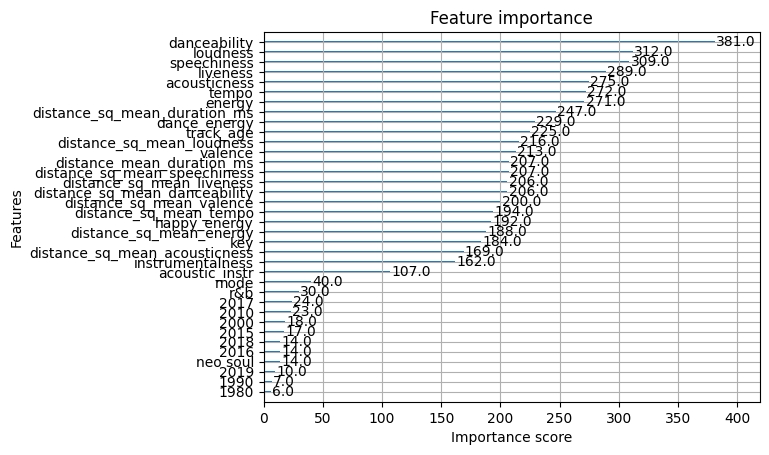

In [25]:
plot_importance = xgb.plot_importance(xgbr)

Con solo features continuas

In [10]:
columnas_continuas = list(X_train.select_dtypes(include='float').columns) + ['track_age']

In [16]:
xgbr = XGBRegressor(n_jobs=-1, random_state=42)

xgbr.fit(
    X_train[columnas_continuas],
    y_train,
    verbose=100)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=-1, num_parallel_tree=None, ...)

In [17]:
print('Prediccion TRAIN')
y_train_pred = xgbr.predict(X_train[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred):.4f}")

print('Prediccion TEST')
y_pred = xgbr.predict(X_test[columnas_continuas])
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 227.9316
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 15.0974
Coeficiente de Determinación (R²): 0.6340
Prediccion TEST
Error Cuadrático Medio (MSE): 493.6371
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.2179
Coeficiente de Determinación (R²): 0.2193


Empiezo a tocar los parametros

In [18]:
xgbr_config = XGBRegressor(

    # boosting
    n_estimators=300,
    learning_rate=0.03,

    # complejidad
    max_depth=5,

    # regularización
    min_child_weight=8,
    gamma=0.2,

    # bagging
    subsample=0.8,
    colsample_bytree=0.8,

    # regularización extra
    reg_alpha=0.5,
    reg_lambda=2,

    # estabilidad
    objective='reg:squarederror',

    random_state=42,
    n_jobs=-1
)

xgbr_config.fit(X_train, y_train, verbose=100)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.2, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=8, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [19]:
print('Prediccion TRAIN')
y_train_pred = xgbr_config.predict(X_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred):.4f}")

print('Prediccion TEST')
y_pred = xgbr_config.predict(X_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 435.8494
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 20.8770
Coeficiente de Determinación (R²): 0.3001
Prediccion TEST
Error Cuadrático Medio (MSE): 507.7303
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 22.5329
Coeficiente de Determinación (R²): 0.1970


#### Optimizacion XGBoost

In [31]:
import warnings
warnings.filterwarnings('ignore')

# ── 1. MODELO BASE ─────────────────────────────────────────────
# XGBoost no necesita StandardScaler
xgb = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',       # mucho más rápido con datasets grandes
    random_state=42,
    n_jobs=-1
)

# ── 2. PASO 1: búsqueda amplia (muestra del 40%) ────────────────
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=0.4, random_state=42
)

param_space_1 = {
    'n_estimators':      Integer(100, 800),
    'learning_rate':     Real(0.01, 0.3,  prior='log-uniform'),
    'max_depth':         Integer(3, 8),
    'subsample':         Real(0.5, 1.0),
    'min_child_weight':  Integer(1, 10),
    'gamma':             Real(0, 1.0),
}

search_1 = BayesSearchCV(
    xgb,
    param_space_1,
    n_iter=30,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),  # cv=3 para rapidez
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_1.fit(X_sample, y_sample)

print("=== PASO 1 — mejores parámetros (muestra) ===")
print(search_1.best_params_)

# ── 3. PASO 2: refinado alrededor del ganador ───────────────────
bp = search_1.best_params_

def narrow(val, pct=0.4, lo=0.01, hi=None):
    """Acota un rango al ±40% del mejor valor encontrado."""
    delta = val * pct
    lower = max(lo, val - delta)
    upper = val + delta
    if hi: upper = min(hi, upper)
    return lower, upper

lr_lo, lr_hi   = narrow(bp['learning_rate'], lo=0.005)
sub_lo, sub_hi = narrow(bp['subsample'], lo=0.4, hi=1.0)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

KeyError: 'colsample_bytree'

In [35]:
search_1.best_params_

OrderedDict([('gamma', 0.0),
             ('learning_rate', 0.01420386074767859),
             ('max_depth', 8),
             ('min_child_weight', 1),
             ('n_estimators', 447),
             ('subsample', 0.5345479005604834)])

Validacion intermedia antes de seguir con optimizacion

In [36]:
xgb_opt = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    **search_1.best_params_
)

In [37]:
xgb_opt.fit(X_train, y_train, verbose=100)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01420386074767859, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=1, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=447, n_jobs=-1,
             num_parallel_tree=None, ...)

In [38]:
print('Prediccion TRAIN')
y_train_pred = xgb_opt.predict(X_train)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_train, y_train_pred):.4f}")

print('Prediccion TEST')
y_pred = xgb_opt.predict(X_test)
print(f"Error Cuadrático Medio (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Raiz Cuadrada del Error Cuadrático Medio (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Coeficiente de Determinación (R²): {r2_score(y_test, y_pred):.4f}")

Prediccion TRAIN
Error Cuadrático Medio (MSE): 286.2393
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 16.9186
Coeficiente de Determinación (R²): 0.5403
Prediccion TEST
Error Cuadrático Medio (MSE): 472.5640
Raiz Cuadrada del Error Cuadrático Medio (RMSE): 21.7385
Coeficiente de Determinación (R²): 0.2526


Seguimos con optimizacion

Tardo 46 mins

In [41]:
param_space_2 = {
    'n_estimators':     Integer(400,600),
    'learning_rate':    Real(lr_lo, lr_hi, prior='log-uniform'),
    'max_depth':        Integer(5,15),
    'subsample':        Real(sub_lo, sub_hi),
    'min_child_weight': Integer(max(1, bp['min_child_weight'] - 2), bp['min_child_weight'] + 3),
    'gamma':            Real(0, max(0.5, bp['gamma'] * 1.5))
}

search_2 = BayesSearchCV(
    xgb,
    param_space_2,
    n_iter=15,
    cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search_2.fit(X_train, y_train)        # dataset completo

print("\n=== PASO 2 — mejores parámetros (dataset completo) ===")
print(search_2.best_params_)
print(f"RMSE (CV): {np.sqrt(-search_2.best_score_):.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits

=== PASO 2 — mejores parámetros (dataset completo) ===
OrderedDict({'gamma': 0.0018151536273716133, 'learning_rate


=== MÉTRICAS EN TEST SET ===
R²:   0.3176
RMSE: 20.7722


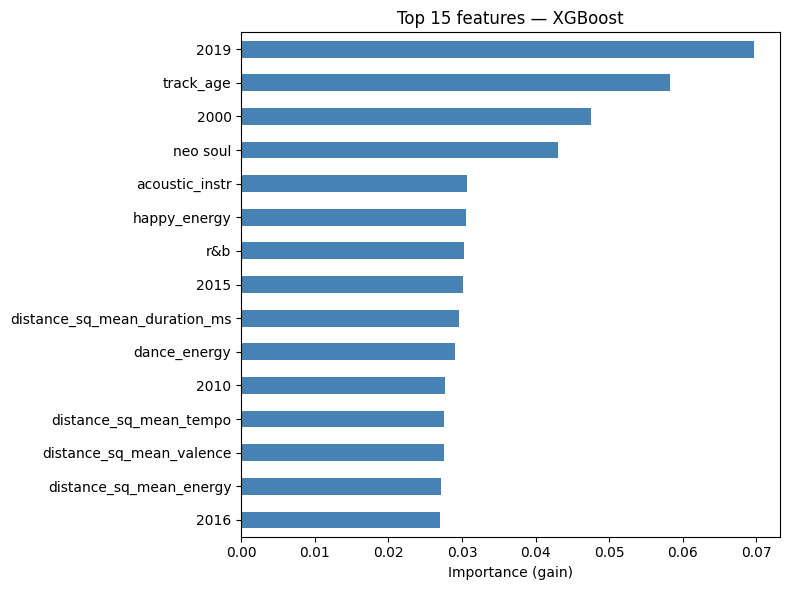

In [42]:
# ── 4. EVALUACIÓN FINAL ─────────────────────────────────────────
best_model = search_2.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== MÉTRICAS EN TEST SET ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# ── 5. FEATURE IMPORTANCE ──────────────────────────────────────
fi = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
fi.tail(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 features — XGBoost')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

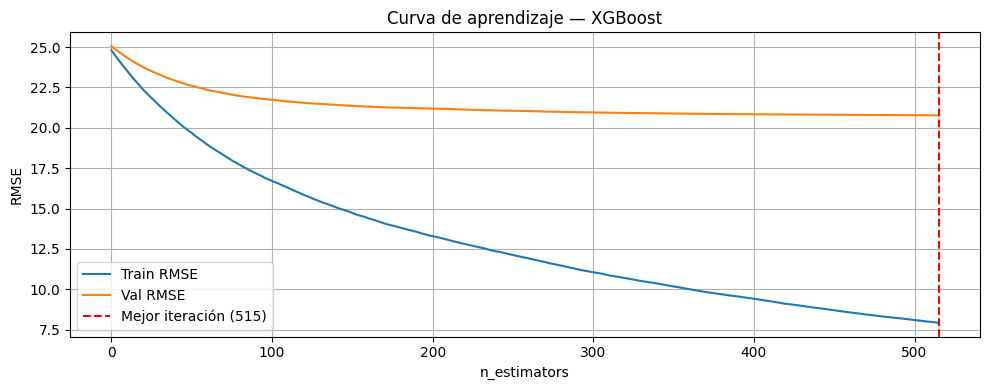

In [45]:
# ── 6. CURVA DE APRENDIZAJE (diagnóstico over/underfit) ─────────

# Alternativa manual con eval_set
final_params = search_2.best_params_
diag_model = XGBRegressor(
    **final_params,
    objective='reg:squarederror',
    tree_method='hist',
    eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1
)
diag_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

evals = diag_model.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(evals['validation_0']['rmse'], label='Train RMSE')
plt.plot(evals['validation_1']['rmse'], label='Val RMSE')
plt.axvline(diag_model.best_iteration, color='red',
            linestyle='--', label=f'Mejor iteración ({diag_model.best_iteration})')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — XGBoost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [50]:
diag_model.save_model('xgb_regressor.json')

#### Submission

In [52]:
dummies_genre_val = pd.get_dummies(df_val['playlist_genre']).astype(int)
dummies_subgenre_val = pd.get_dummies(df_val['playlist_subgenre']).astype(int)
dummies_grupo_anio_val = pd.get_dummies(df_val['grupo_anio']).astype(int)
variables_ML = ['danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'distance_mean_danceability',
       'distance_sq_mean_danceability', 'distance_mean_energy',
       'distance_sq_mean_energy', 'distance_mean_loudness',
       'distance_sq_mean_loudness', 'distance_mean_speechiness',
       'distance_sq_mean_speechiness', 'distance_mean_acousticness',
       'distance_sq_mean_acousticness', 'distance_mean_liveness',
       'distance_sq_mean_liveness', 'distance_mean_valence',
       'distance_sq_mean_valence', 'distance_mean_tempo',
       'distance_sq_mean_tempo', 'distance_mean_duration_ms',
       'distance_sq_mean_duration_ms', 'dance_energy', 'happy_energy',
       'acoustic_instr', 'duration_min', 'track_age']

df_val_ML = pd.concat([df_val[variables_ML], dummies_genre_val[['r&b']], dummies_subgenre_val[['neo soul']], dummies_grupo_anio_val], axis=1)

In [54]:
df_val_ML.columns = df_val_ML.columns.astype(str)

In [55]:
X_validation = df_val_ML[list(X_train.columns)]

y_pred_xgb = diag_model.predict(X_validation)

In [58]:
submission_df_cb = pd.DataFrame({
    'ID': list(df_val.index),
    'track_popularity': y_pred_xgb
})

submission_df_cb.to_csv('submission_xgb.csv', index=False)

### TabNet regressor

In [46]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.0 MB/s eta 0:00:00


In [47]:
import numpy as np
import pandas as pd
import torch
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ── 1. ESCALADO (TabNet sí se beneficia de escalar) ────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── 2. MODELO ──────────────────────────────────────────────────
reg = TabNetRegressor(
    n_d=24,
    n_a=24,
    n_steps=3,                 # bajado de 5 → menos overfit con pocos datos
    gamma=1.5,
    lambda_sparse=1e-3,        # subido de 1e-5 → más regularización sparse
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),          # bajado de 0.01
    scheduler_fn=torch.optim.lr_scheduler.CosineAnnealingLR,
    scheduler_params={"T_max": 50, "eta_min": 1e-5},
    mask_type='sparsemax',
    seed=42,
    verbose=10                 # imprime métricas cada 10 épocas
)

# ── 3. ENTRENAMIENTO ───────────────────────────────────────────
reg.fit(
    X_train_scaled, y_train.values.reshape(-1, 1),
    eval_set=[(X_test_scaled, y_test.values.reshape(-1, 1))],
    eval_name=['val'],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=512,            # bajado de 1024 → más actualizaciones por época
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# ── 4. EVALUACIÓN ──────────────────────────────────────────────
y_pred = reg.predict(X_test_scaled)

print("=== MÉTRICAS EN TEST SET ===")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

epoch 0  | loss: 2378.2391| val_rmse: 47.41321|  0:00:05s
epoch 10 | loss: 578.18159| val_rmse: 24.12685|  0:00:30s
epoch 20 | loss: 548.952 | val_rmse: 23.66119|  0:00:54s
epoch 30 | loss: 532.54672| val_rmse: 23.49745|  0:01:19s
epoch 40 | loss: 525.85139| val_rmse: 23.4546 |  0:01:45s
epoch 50 | loss: 526.55248| val_rmse: 23.42745|  0:02:11s
epoch 60 | loss: 525.8473| val_rmse: 23.4238 |  0:02:35s
epoch 70 | loss: 521.20158| val_rmse: 23.39049|  0:03:00s
epoch 80 | loss: 515.51742| val_rmse: 23.33037|  0:03:23s
epoch 90 | loss: 508.31923| val_rmse: 23.26755|  0:03:47s
epoch 100| loss: 501.96342| val_rmse: 23.31285|  0:04:12s
epoch 110| loss: 489.9738| val_rmse: 23.32441|  0:04:35s

Early stopping occurred at epoch 113 with best_epoch = 93 and best_val_rmse = 23.20289
=== MÉTRICAS EN TEST SET ===
R²:   0.1485
RMSE: 23.2029


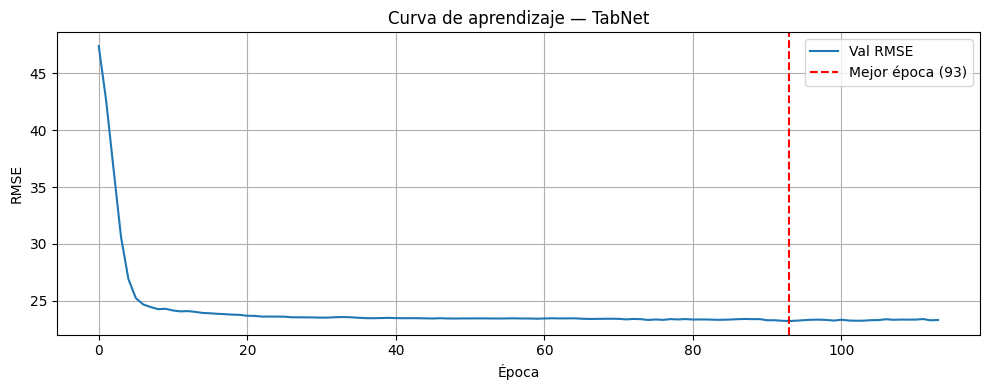

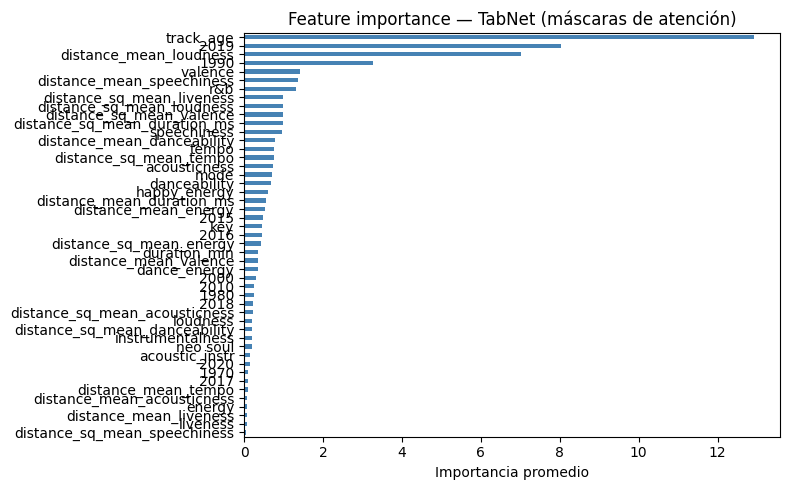

Successfully saved model at tabnet_regressor.zip


'tabnet_regressor.zip'

In [48]:
# ── 5. CURVA DE APRENDIZAJE ────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(reg.history['val_rmse'], label='Val RMSE')
plt.axvline(np.argmin(reg.history['val_rmse']),
            color='red', linestyle='--',
            label=f"Mejor época ({np.argmin(reg.history['val_rmse'])})")
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.title('Curva de aprendizaje — TabNet')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('tabnet_learning_curve.png', dpi=150)
plt.show()

# ── 6. MÁSCARAS DE ATENCIÓN (interpretabilidad) ────────────────
# Qué features usó el modelo en cada predicción
masks = reg.explain(X_test_scaled)
feature_importance = masks[0].mean(axis=0)

fi_series = pd.Series(feature_importance, index=X_train.columns)\
              .sort_values(ascending=True)

plt.figure(figsize=(8, 5))
fi_series.plot(kind='barh', color='steelblue')
plt.title('Feature importance — TabNet (máscaras de atención)')
plt.xlabel('Importancia promedio')
plt.tight_layout()
plt.savefig('tabnet_feature_importance.png', dpi=150)
plt.show()

# ── 7. GUARDAR Y CARGAR EL MODELO ─────────────────────────────
reg.save_model('tabnet_regressor')
# Para cargar:
# reg_loaded = TabNetRegressor()
# reg_loaded.load_model('tabnet_regressor.zip')